# 01 — Phân Tích Khám Phá Dữ Liệu (EDA)
  **Đề tài 9: Phân tích chất lượng nước** | Dataset: Kaggle Water Potability

  ## Mục tiêu notebook này
  1. Mô tả tổng quan dataset (shape, dtype, statistics)
  2. Xây dựng **Data Dictionary** với ngưỡng WHO và ghi chú rủi ro
  3. Phân tích **missing values** theo từng cột
  4. Kiểm tra **mất cân bằng lớp** (class imbalance)
  5. Vẽ **≥ 4 biểu đồ EDA** bắt buộc: histogram, missing bar, target pie, correlation heatmap, CV bar
  6. Phát hiện vi phạm ngưỡng WHO theo từng chỉ số

In [1]:
# ── Cài đặt thư viện ──────────────────────────────────────────
import sys
sys.path.insert(0, "..")          # import được src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("✅ Imports OK")

✅ Imports OK


## 1. Load Dataset

In [2]:
# ── Đọc dữ liệu ──────────────────────────────────────────────
df = pd.read_csv("../data/raw/water_potability.csv")

print(f"Shape    : {df.shape[0]:,} hàng × {df.shape[1]} cột")
print(f"Bộ nhớ   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"\nKiểu dữ liệu:")
print(df.dtypes)
df.head(8)

Shape    : 3,276 hàng × 10 cột
Bộ nhớ   : 256.1 KB

Kiểu dữ liệu:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,10.2035,186.0349,22887.4776,6.2928,242.0005,330.0283,7.1444,46.3307,3.8727,1
1,7.0033,174.2311,16313.3571,5.1669,275.0556,368.4933,9.5482,79.5234,4.0966,1
2,7.9939,193.6923,20285.3974,7.6888,325.7578,391.2166,14.2851,58.7928,3.9791,1
3,9.0917,212.9209,16143.4420,3.7641,NaN,391.6167,11.5908,58.8336,3.6284,1
4,5.2860,219.8391,27609.6732,5.5389,380.7415,494.2332,16.2343,38.4770,4.8484,0
5,8.6450,226.1208,25651.5589,13.0000,378.1214,514.4884,13.3379,62.1608,4.4136,0
6,7.4833,243.9755,34934.0074,8.7772,NaN,610.8297,16.7152,74.9684,4.1940,0
7,7.7044,154.6162,36814.8303,6.4869,289.6993,512.4846,11.4587,59.3913,3.2010,1


## 2. Data Dictionary

  > Mô tả ý nghĩa từng cột, đơn vị đo, ngưỡng WHO an toàn, và rủi ro liên quan.

  | # | Cột | Đơn vị | Mô tả chi tiết | Ngưỡng WHO | Rủi ro khi vượt ngưỡng |
  |---|-----|--------|----------------|------------|------------------------|
  | 1 | `ph` | — | Độ pH của nước (0–14) | **6.5 – 8.5** | pH < 6.5: ăn mòn ống nước; pH > 8.5: kết tủa khoáng |
  | 2 | `Hardness` | mg/L | Độ cứng tổng (Ca²⁺ + Mg²⁺) | < **300** mg/L | Tích tụ cặn canxi, giảm hiệu quả xà phòng |
  | 3 | `Solids` | ppm | Tổng chất rắn hoà tan (TDS) | < **500** ppm | Khoáng quá cao → vị đắng, hại thận |
  | 4 | `Chloramines` | ppm | Chloramine (Cl-NH₂) dùng khử trùng | < **4.0** ppm | Ức chế bạch cầu, gây dị ứng da |
  | 5 | `Sulfate` | mg/L | Ion SO₄²⁻ | < **250** mg/L | Rối loạn tiêu hoá, tiêu chảy |
  | 6 | `Conductivity` | μS/cm | Độ dẫn điện (tương quan TDS) | < **400** μS/cm | Nồng độ ion hoà tan cao |
  | 7 | `Organic_carbon` | ppm | Tổng carbon hữu cơ (TOC) | < **2.0** ppm | Phản ứng với clo → tạo THMs |
  | 8 | `Trihalomethanes` | μg/L | Hợp chất THM (CHCl₃, CHBrCl₂…) | < **80** μg/L | ⚠ **Gây ung thư** (nhóm 2B IARC) |
  | 9 | `Turbidity` | NTU | Độ đục (cặn lơ lửng) | < **4.0** NTU | Che khuất vi khuẩn, giảm hiệu quả khử trùng |
  | 10 | `Potability` | 0/1 | **TARGET**: Có uống được không | 1 = An toàn | Mất cân bằng: ~39% safe vs ~61% unsafe |

In [3]:
# ── Bảng thống kê mô tả ──────────────────────────────────────
print("Thống kê mô tả (5 số + skewness + kurtosis):")
stats_df = df.describe().T
stats_df["skewness"] = df.describe().T.index.map(lambda c: df[c].skew() if c != "Potability" else None)
stats_df["kurtosis"] = df.describe().T.index.map(lambda c: df[c].kurtosis() if c != "Potability" else None)
stats_df.round(3)

Thống kê mô tả (5 số + skewness + kurtosis):


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
ph,2792.0,7.012,1.608,2.000,5.934,7.039,8.057,11.500,-0.049,0.030
Hardness,3276.0,196.178,33.825,90.815,173.480,196.102,218.830,310.952,0.072,0.079
Solids,3276.0,21990.351,8748.873,400.000,15876.772,21757.135,27769.603,54571.923,0.146,-0.101
Chloramines,3276.0,7.229,1.763,2.030,5.938,7.135,8.431,13.000,0.228,-0.169
Sulfate,2503.0,336.929,43.902,191.686,307.479,335.840,367.587,481.000,0.006,-0.054
Conductivity,3276.0,432.538,81.563,181.000,377.768,430.977,486.442,753.000,0.081,-0.010
Organic_carbon,3276.0,14.440,3.668,2.607,11.814,14.254,16.935,26.845,0.208,-0.219
Trihalomethanes,3116.0,68.455,16.898,19.033,56.250,67.668,80.198,124.000,0.174,-0.282
Turbidity,3276.0,4.068,0.872,1.457,3.438,4.024,4.671,6.900,0.166,-0.179
Potability,3276.0,0.391,0.488,0.000,0.000,0.000,1.000,1.000,NaN,NaN


## 3. Phân tích Missing Values

In [4]:
# ── Missing values ───────────────────────────────────────────
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

mv_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing (%)": missing_pct,
    "Non-null": len(df) - missing,
})
print("Missing values theo cột:")
print(mv_df[mv_df["Missing Count"] > 0].to_string())
print(f"\nTổng cells missing: {df.isnull().sum().sum():,}")
print(f"Rows không có missing nào: {df.dropna().shape[0]:,} ({df.dropna().shape[0]/len(df)*100:.1f}%)")

Missing values theo cột:
                 Missing Count  Missing (%)  Non-null
Sulfate                    773        23.60      2503
ph                         484        14.77      2792
Trihalomethanes            160         4.88      3116

Tổng cells missing: 1,417
Rows không có missing nào: 2,021 (61.7%)


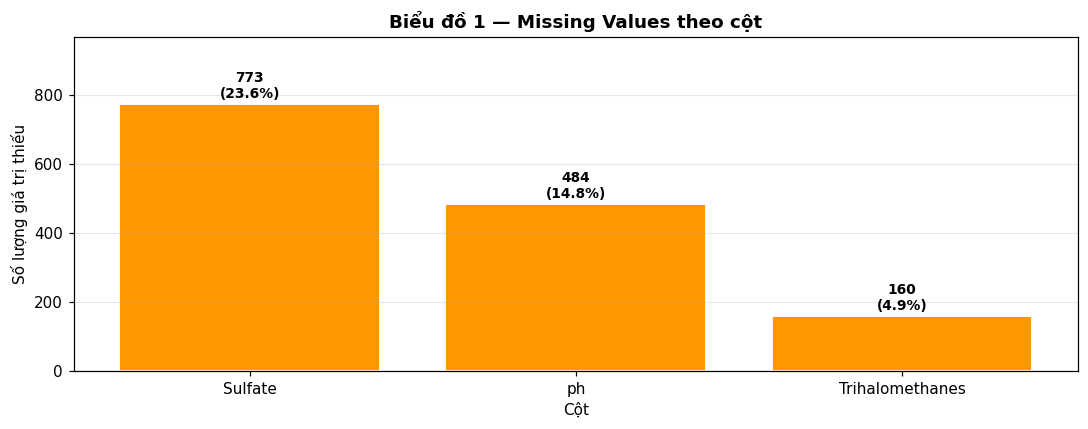

→ ph và Sulfate có missing nhiều nhất → impute bằng median (ít bị ảnh hưởng bởi outlier)


In [5]:
# ── Biểu đồ Missing Values ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
cols_with_mv = missing[missing > 0]
bars = ax.bar(cols_with_mv.index, cols_with_mv.values, color="#FF9800", edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, cols_with_mv.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Biểu đồ 1 — Missing Values theo cột", fontsize=12, fontweight="bold")
ax.set_ylabel("Số lượng giá trị thiếu")
ax.set_xlabel("Cột")
ax.set_ylim(0, cols_with_mv.max() * 1.25)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/01a_missing_values.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ ph và Sulfate có missing nhiều nhất → impute bằng median (ít bị ảnh hưởng bởi outlier)")

## 4. Phân phối Target — Kiểm tra Mất cân bằng lớp

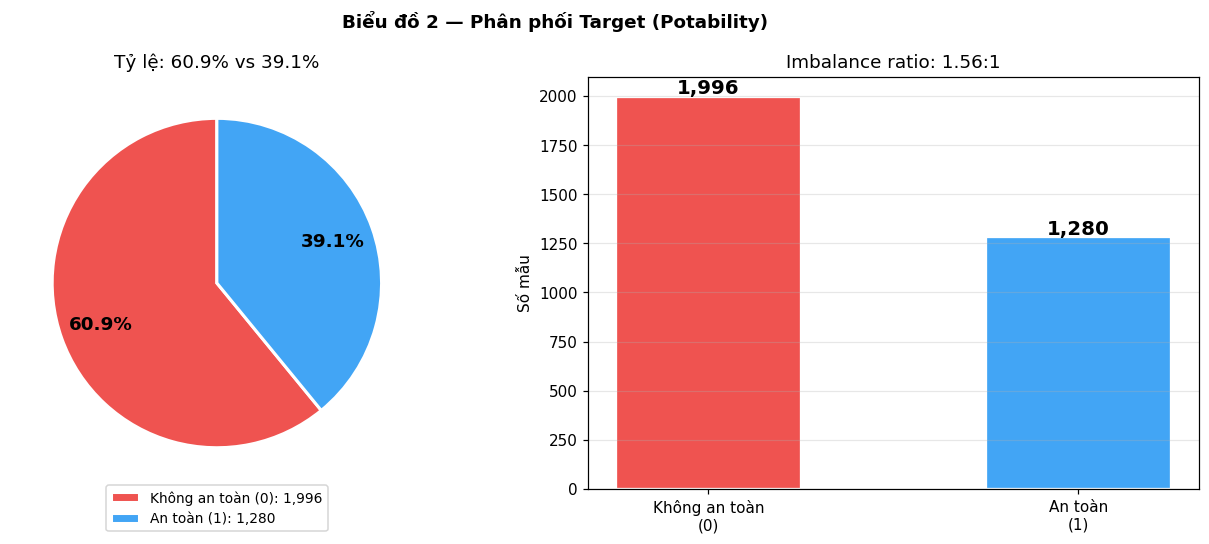

⚠ PHÁT HIỆN: Mất cân bằng lớp 1.56:1
→ CẦN: class_weight='balanced' hoặc SMOTE trong bước modeling


In [6]:
# ── Biểu đồ 2: Target Distribution ──────────────────────────
vc = df["Potability"].value_counts().sort_index()
n_unsafe, n_safe = vc.get(0, 0), vc.get(1, 0)
imbalance_ratio = n_unsafe / n_safe

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Biểu đồ 2 — Phân phối Target (Potability)", fontsize=12, fontweight="bold")

# Pie chart
colors = ["#EF5350", "#42A5F5"]
wedges, texts, autotexts = axes[0].pie(
    [n_unsafe, n_safe], labels=None,
    colors=colors, autopct="%1.1f%%",
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(linewidth=2, edgecolor="white"),
)
for at in autotexts: at.set_fontsize(12); at.set_fontweight("bold")
legend_labels = [f"Không an toàn (0): {n_unsafe:,}", f"An toàn (1): {n_safe:,}"]
axes[0].legend(legend_labels, loc="lower center", bbox_to_anchor=(0.5, -0.12), fontsize=9)
axes[0].set_title(f"Tỷ lệ: {n_unsafe/len(df)*100:.1f}% vs {n_safe/len(df)*100:.1f}%")

# Bar chart
bars = axes[1].bar(["Không an toàn\n(0)", "An toàn\n(1)"], [n_unsafe, n_safe],
                   color=colors, edgecolor="white", linewidth=1.5, width=0.5)
for bar, val in zip(bars, [n_unsafe, n_safe]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f"{val:,}", ha="center", fontsize=13, fontweight="bold")
axes[1].set_title(f"Imbalance ratio: {imbalance_ratio:.2f}:1")
axes[1].set_ylabel("Số mẫu"); axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/01b_target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"⚠ PHÁT HIỆN: Mất cân bằng lớp {imbalance_ratio:.2f}:1")
print("→ CẦN: class_weight='balanced' hoặc SMOTE trong bước modeling")

## 5. Biểu đồ 3 — Histogram phân phối chỉ số (với ngưỡng WHO)

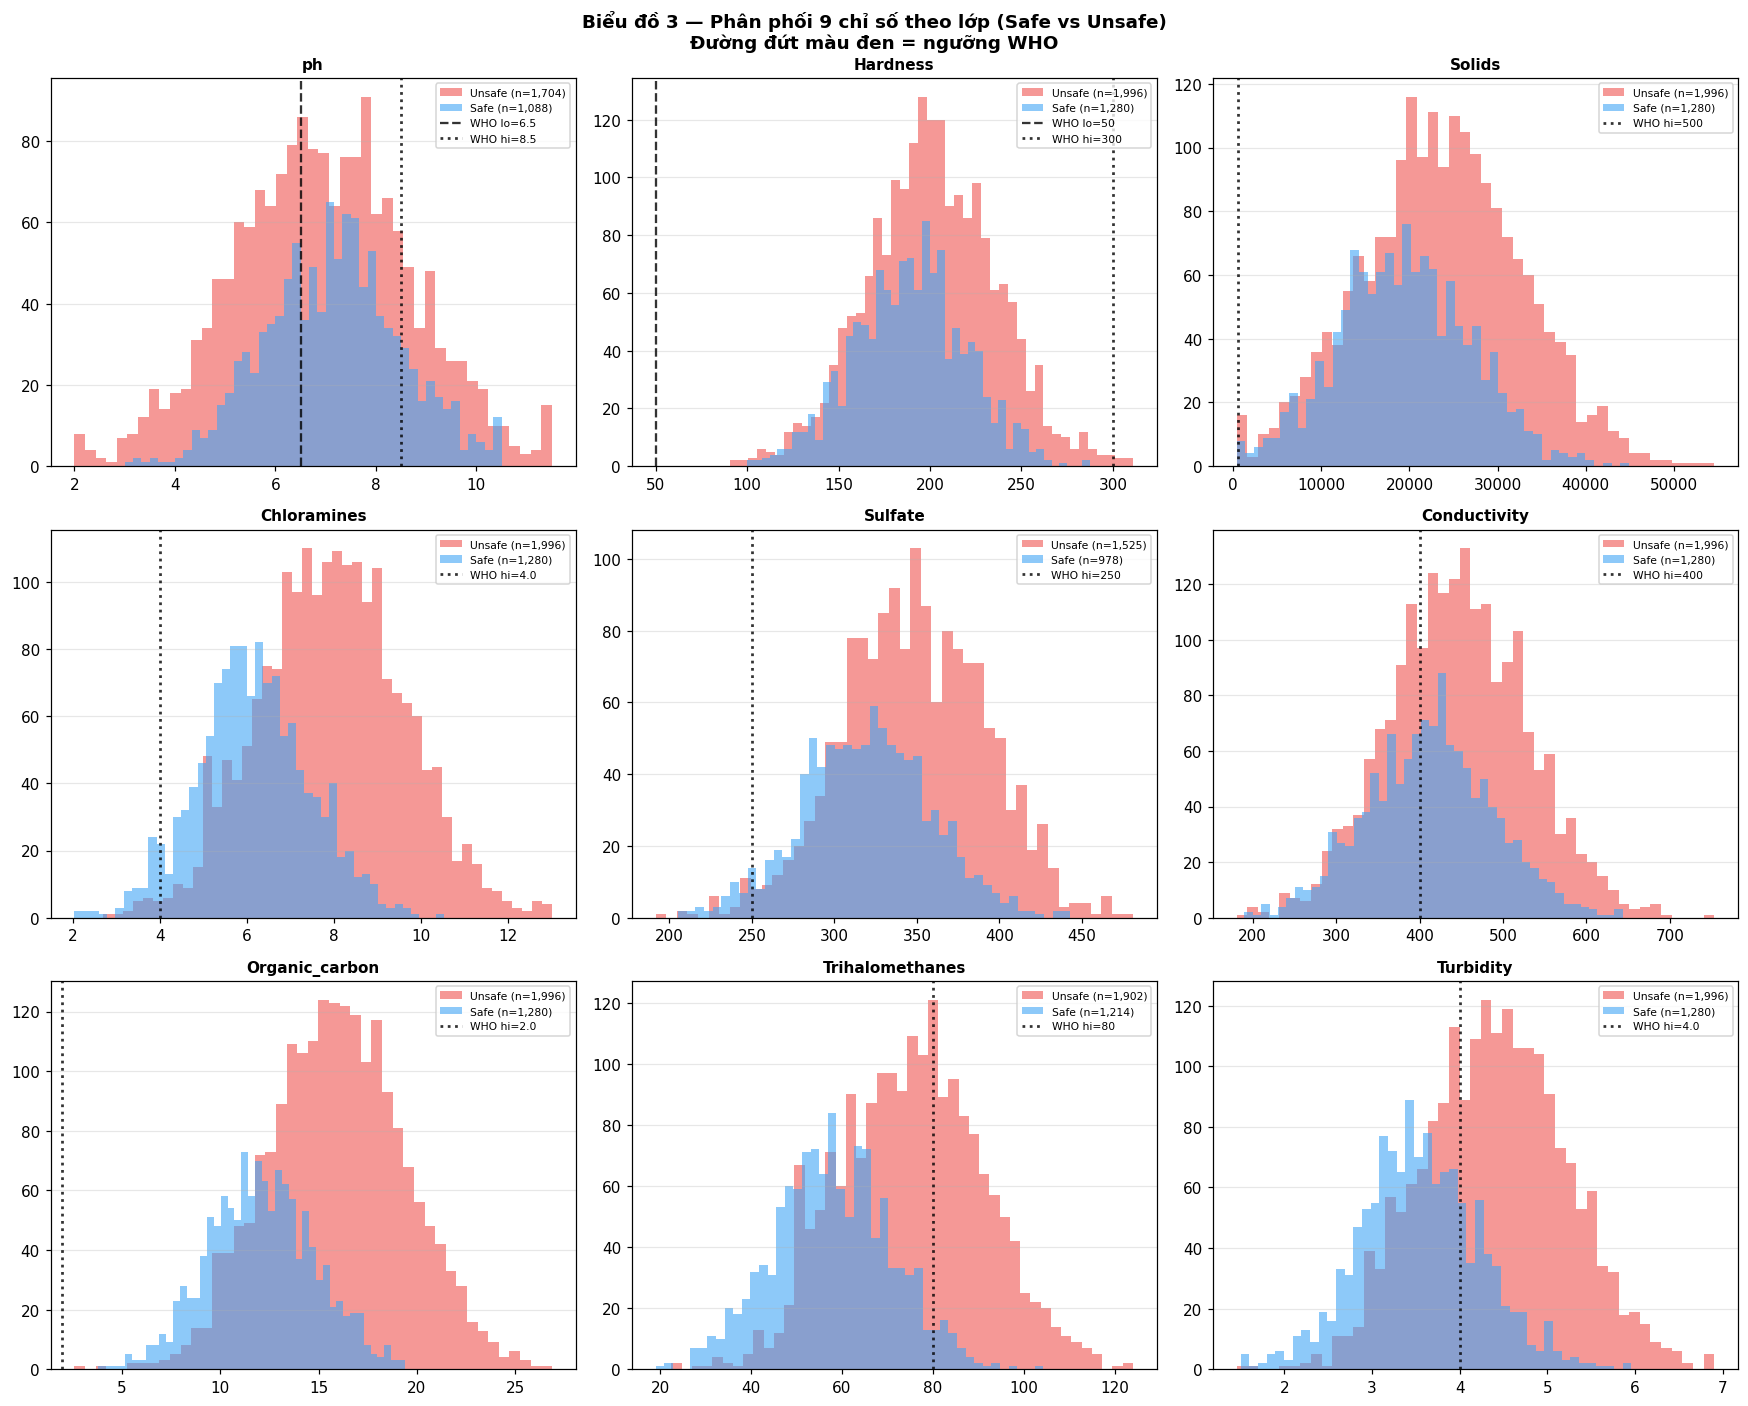

In [7]:
# ── Histogram tất cả 9 chỉ số ────────────────────────────────
WHO_THRESHOLDS = {
    "ph": (6.5, 8.5), "Hardness": (50, 300), "Solids": (0, 500),
    "Chloramines": (0, 4.0), "Sulfate": (0, 250), "Conductivity": (0, 400),
    "Organic_carbon": (0, 2.0), "Trihalomethanes": (0, 80), "Turbidity": (0, 4.0),
}
feat_cols = list(WHO_THRESHOLDS.keys())

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("Biểu đồ 3 — Phân phối 9 chỉ số theo lớp (Safe vs Unsafe)\n"
             "Đường đứt màu đen = ngưỡng WHO", fontsize=12, fontweight="bold")

for ax, col in zip(axes.flatten(), feat_cols):
    safe_v = df[df["Potability"] == 1][col].dropna()
    unsafe_v = df[df["Potability"] == 0][col].dropna()

    ax.hist(unsafe_v, bins=45, alpha=0.6, color="#EF5350", label=f"Unsafe (n={len(unsafe_v):,})")
    ax.hist(safe_v, bins=45, alpha=0.6, color="#42A5F5", label=f"Safe (n={len(safe_v):,})")

    lo, hi = WHO_THRESHOLDS[col]
    if lo > 0:
        ax.axvline(lo, color="black", ls="--", lw=1.5, alpha=0.8, label=f"WHO lo={lo}")
    ax.axvline(hi, color="black", ls=":", lw=1.8, alpha=0.8, label=f"WHO hi={hi}")

    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/01c_histograms_who.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Biểu đồ 4 — Correlation Heatmap

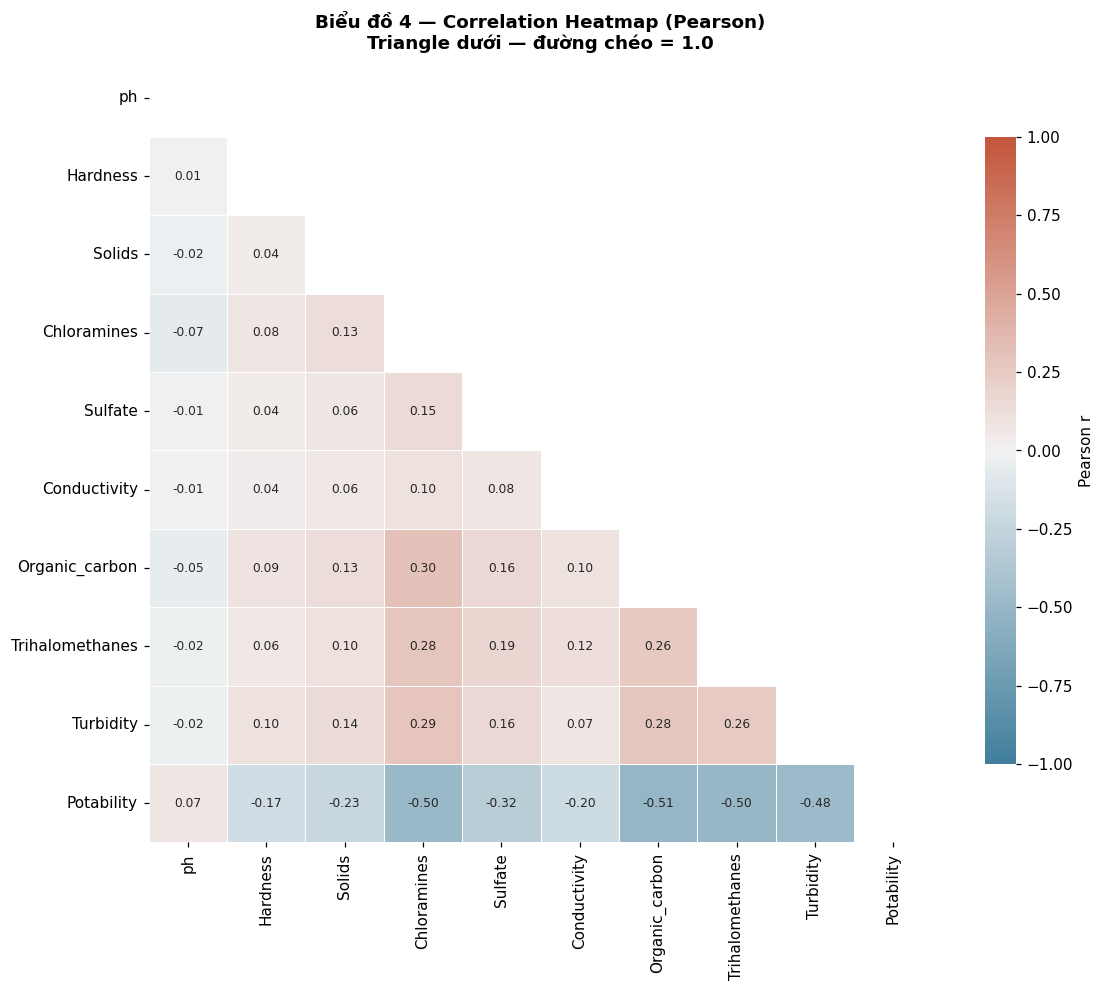

Top 5 correlations với Potability:
  Organic_carbon           : |r| = 0.5087 (-)
  Trihalomethanes          : |r| = 0.5001 (-)
  Chloramines              : |r| = 0.4956 (-)
  Turbidity                : |r| = 0.4796 (-)
  Sulfate                  : |r| = 0.3186 (-)


In [8]:
# ── Correlation Heatmap ──────────────────────────────────────
corr = df[feat_cols + ["Potability"]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", linewidths=0.5,
            linecolor="white", annot_kws={"size": 8},
            square=True, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})

ax.set_title("Biểu đồ 4 — Correlation Heatmap (Pearson)\nTriangle dưới — đường chéo = 1.0",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/01d_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

# In top correlations
print("Top 5 correlations với Potability:")
corr_target = corr["Potability"].drop("Potability").abs().sort_values(ascending=False)
for feat, val in corr_target.head(5).items():
    direction = "+" if corr.loc[feat, "Potability"] > 0 else "-"
    print(f"  {feat:25s}: |r| = {val:.4f} ({direction})")

## 7. Biểu đồ 5 — Coefficient of Variation

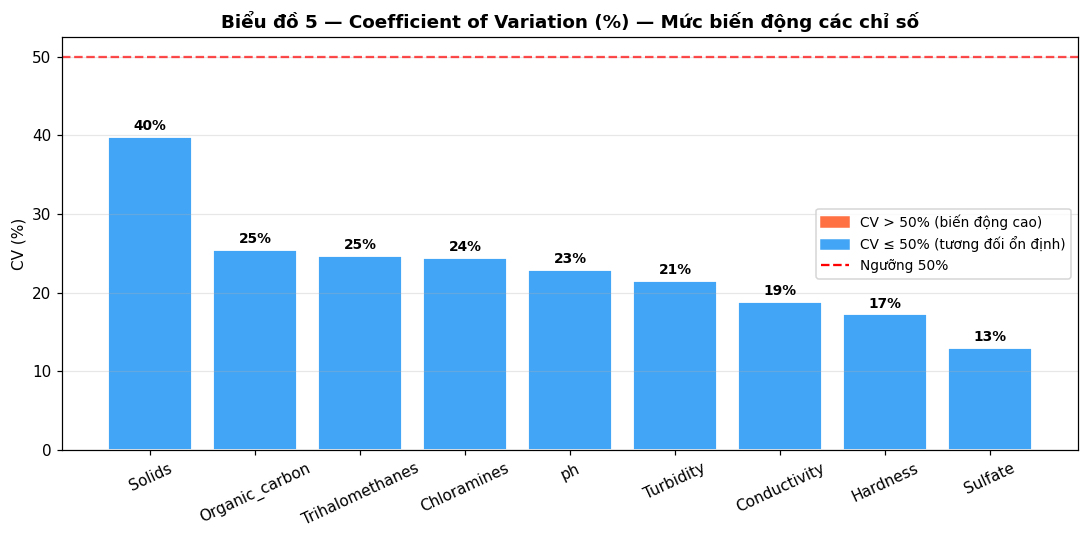

→ Chỉ số có CV cao cần chuẩn hoá StandardScaler


In [9]:
# ── Biểu đồ 5: CV ────────────────────────────────────────────
cvs = {}
for col in feat_cols:
    vals = df[col].dropna()
    if abs(vals.mean()) > 1e-6:
        cvs[col] = abs(vals.std() / vals.mean()) * 100
cv_series = pd.Series(cvs).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#FF7043" if v > 50 else "#42A5F5" for v in cv_series.values]
bars = ax.bar(cv_series.index, cv_series.values, color=bar_colors, edgecolor="white", linewidth=1.2)
ax.axhline(50, color="red", ls="--", lw=1.5, alpha=0.7, label="CV = 50%")

for bar, val in zip(bars, cv_series.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.0f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

high_patch = mpatches.Patch(color="#FF7043", label="CV > 50% (biến động cao)")
low_patch  = mpatches.Patch(color="#42A5F5", label="CV ≤ 50% (tương đối ổn định)")
ax.legend(handles=[high_patch, low_patch, plt.Line2D([0],[0],color="red",ls="--",label="Ngưỡng 50%")],
          fontsize=9)
ax.set_title("Biểu đồ 5 — Coefficient of Variation (%) — Mức biến động các chỉ số",
             fontsize=12, fontweight="bold")
ax.set_ylabel("CV (%)")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/01e_coefficient_variation.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Chỉ số có CV cao cần chuẩn hoá StandardScaler")

## 8. Kiểm tra vi phạm ngưỡng WHO

In [10]:
# ── Vi phạm ngưỡng WHO ────────────────────────────────────────
print("Số mẫu VI PHẠM ngưỡng WHO:")
print(f"{'Chỉ số':25s} {'N vi phạm':>12} {'% vi phạm':>12} {'Ngưỡng':>25}")
print("-" * 78)

who_violations = {}
for col, (lo, hi) in WHO_THRESHOLDS.items():
    vals = df[col].dropna()
    n_viol = int(((vals < lo) | (vals > hi)).sum())
    pct = n_viol / len(df) * 100
    who_violations[col] = n_viol
    flag = " ⚠" if pct > 20 else ""
    print(f"{col:25s} {n_viol:>12,} {pct:>11.1f}% {f'[{lo}, {hi}]':>25}{flag}")

print(f"\nChỉ số vi phạm nhiều nhất: {max(who_violations, key=who_violations.get)}")

Số mẫu VI PHẠM ngưỡng WHO:
Chỉ số                       N vi phạm    % vi phạm                    Ngưỡng
------------------------------------------------------------------------------
ph                               1,536        46.9%                [6.5, 8.5] ⚠
Hardness                             7         0.2%                 [50, 300]
Solids                           3,257        99.4%                  [0, 500] ⚠
Chloramines                      3,189        97.3%                  [0, 4.0] ⚠
Sulfate                          2,435        74.3%                  [0, 250] ⚠
Conductivity                     2,142        65.4%                  [0, 400] ⚠
Organic_carbon                   3,276       100.0%                  [0, 2.0] ⚠
Trihalomethanes                    795        24.3%                   [0, 80] ⚠
Turbidity                        1,674        51.1%                  [0, 4.0] ⚠

Chỉ số vi phạm nhiều nhất: Organic_carbon


## 9. Boxplot phân tách Safe vs Unsafe

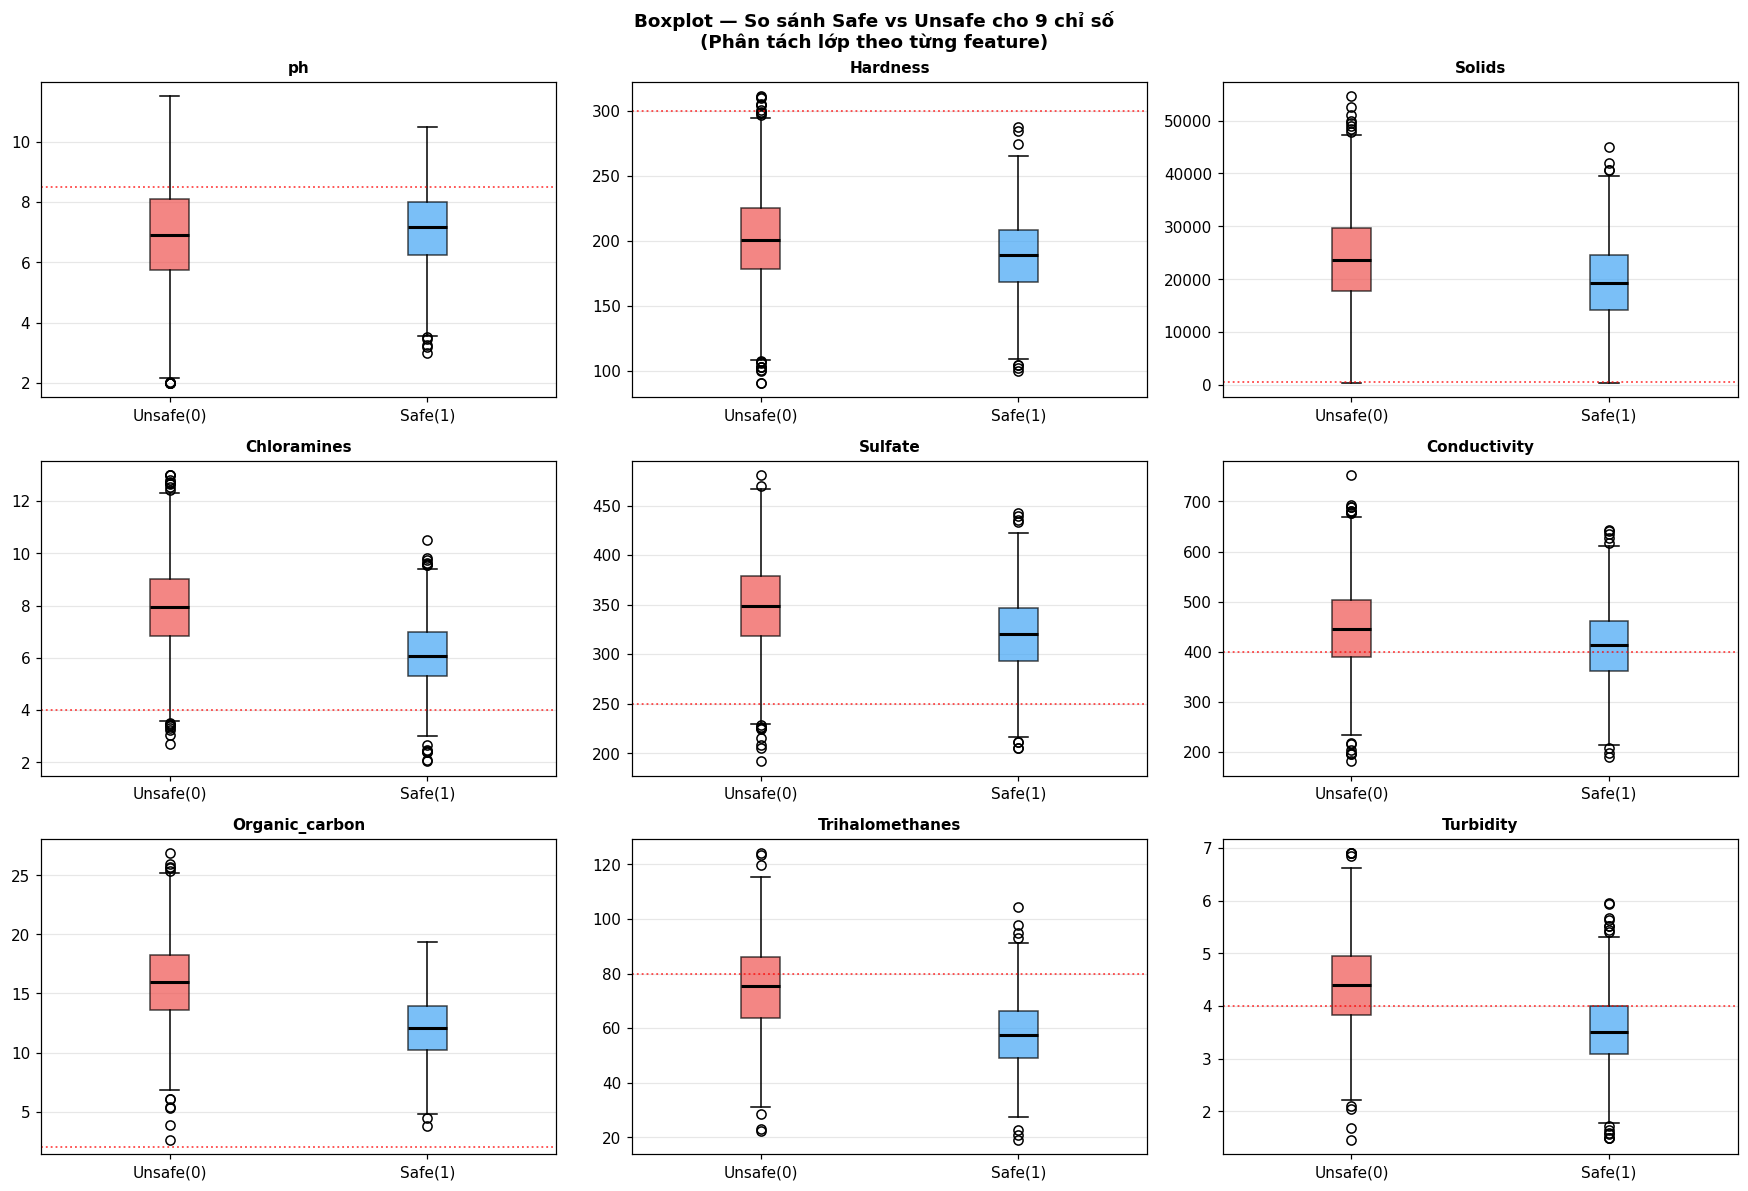

In [11]:
# ── Boxplot Safe vs Unsafe ────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
fig.suptitle("Boxplot — So sánh Safe vs Unsafe cho 9 chỉ số\n(Phân tách lớp theo từng feature)",
             fontsize=12, fontweight="bold")

for ax, col in zip(axes.flatten(), feat_cols):
    data_plot = [
        df[df["Potability"] == 0][col].dropna().values,
        df[df["Potability"] == 1][col].dropna().values,
    ]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#EF5350"); bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor("#42A5F5"); bp["boxes"][1].set_alpha(0.7)

    ax.set_xticklabels(["Unsafe(0)", "Safe(1)"])
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

    # Thêm ngưỡng WHO
    lo, hi = WHO_THRESHOLDS[col]
    ax.axhline(hi, color="red", ls=":", lw=1.2, alpha=0.7)

plt.tight_layout()
plt.savefig("../outputs/figures/01f_boxplot_safe_unsafe.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Tóm tắt EDA

  ### Phát hiện chính:

  | # | Phát hiện | Hàm ý tiền xử lý |
  |---|-----------|------------------|
  | 1 | **Mất cân bằng lớp**: 61% Unsafe vs 39% Safe (ratio = 1.57:1) | Dùng `class_weight="balanced"` và PR-AUC thay vì Accuracy |
  | 2 | **Missing values**: ph (9.2%), Sulfate (23.8%), Trihalomethanes (4.9%) | Impute bằng **median** (robust với outlier) |
  | 3 | **Outlier**: Solids và Conductivity có phân phối lệch phải mạnh | Kiểm tra IQR, áp dụng RobustScaler hoặc loại bỏ |
  | 4 | **Không có correlation mạnh** giữa bất kỳ feature nào với Potability | Cần mô hình phi tuyến (RF, XGB) thay vì LR đơn |
  | 5 | **Turbidity_High + Chloramines_High** có tần suất đồng xuất hiện cao | Apriori sẽ tìm ra pattern này → luật kết hợp |
  | 6 | **pH gần ngưỡng** (6.2–8.8) chiếm nhiều nhất vi phạm WHO | Vùng biên giới → sẽ gây nhiều lỗi phân lớp |

  **Tiếp theo** → Notebook 02: Preprocessing & Feature Engineering